# 06 — Supplementary parameter & robustness figures

Consolidates the supplementary experiments that justify the pipeline's design
choices, each reading artifacts produced by earlier notebooks:

* **Fig S1 — matching-tolerance sweep** (from `03a` Hungarian ppm-tolerance and `03b`
  Gaussian σ sweeps): retrieval vs. the peak-matching tolerance.
* **Fig S2 — spectral richness** (from the `04` ranked lists): retrieval and query
  coverage as a function of the number of peaks in the query spectrum.

All panels are saved to `data/figures/` at 400 dpi.


## 0 · Imports & configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

from dept_similarity.constants import PROCESSED_DATA_DIR, RESULTS_DIR

FIG_DIR = Path(PROCESSED_DATA_DIR).parent / "figures"
OPT_DIR = Path(RESULTS_DIR) / "optimization"
DPI = 400

# Shared palette (consistent with Figures 2 & 5).
AMBER = "#D89168"   # Gaussian
SLATE = "#4E6E81"   # DEPT-Match / alt series
BROWN = "#6B3520"
GREY  = "#8A8A8A"
plt.rcParams.update({"font.size": 13, "axes.spines.top": False, "axes.spines.right": False})

## 1 · Fig S1 — Matching-tolerance sweep

`03a` sweeps the Hungarian peak-matching tolerance (cosine similarity, ppm) and `03b`
sweeps the Gaussian kernel width σ (ppm), both over the full 648-molecule validation set.
Both parameters control how far apart two peaks can be and still be considered the same
signal. Too tight and true peaks are missed to referencing/solvent shifts; too loose and
unrelated peaks match spuriously. The operating points used in the main analysis
(Hungarian tol = 3.0 ppm, Gaussian σ = 2.5 ppm; the Hits@10 optima) are marked.

In [ ]:
from matplotlib.lines import Line2D

hung = pd.read_parquet(OPT_DIR / "hungarian" / "summary_hits_at_k.parquet")
gauss = pd.read_parquet(OPT_DIR / "gaussian" / "summary_hits_at_k.parquet")

kcol = {1: ("#F0C98A", "@1"), 5: ("#D89168", "@5"), 10: ("#6B3520", "@10")}
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# -- DEPT-Match (Hungarian): cosine (solid) vs Jaccard (dashed) --
# The scoring metric barely moves retrieval: cosine and Jaccard track each other and share
# the same optimum, showing the peak-alignment tolerance — not the metric — drives
# performance. This is the evidence for carrying cosine forward.
axH = axes[0]
for k, (c, lbl) in kcol.items():
    axH.plot(hung["ppm_tolerance"], hung[f"Hits@{k} cosine (%)"], "-o", color=c, lw=2, ms=5)
    axH.plot(hung["ppm_tolerance"], hung[f"Hits@{k} jaccard (%)"], "--s", color=c, lw=1.6, ms=4, alpha=0.85)
axH.axvline(3.0, color=GREY, ls="--", lw=1.4)
axH.text(3.0, axH.get_ylim()[0], " tol = 3.0", color=GREY, fontsize=11, va="bottom")
axH.set_title("DEPT-Match — Hungarian assignment", fontsize=14)
axH.set_xlabel(r"chemical-shift $\delta$ (ppm)", fontsize=13)
k_handles = [Line2D([0], [0], color=c, marker="o", lw=2, label=lbl) for k, (c, lbl) in kcol.items()]
m_handles = [Line2D([0], [0], color=GREY, ls="-", lw=2, label="Cosine"),
             Line2D([0], [0], color=GREY, ls="--", lw=1.6, marker="s", ms=4, label="Jaccard")]
leg_k = axH.legend(handles=k_handles, title="Top-k", frameon=False, fontsize=11,
                   title_fontsize=12, loc="lower right")
axH.add_artist(leg_k)
axH.legend(handles=m_handles, title="Metric", frameon=False, fontsize=11,
           title_fontsize=12, loc="upper left")

# -- Gaussian (cosine only) --
axG = axes[1]
for k, (c, lbl) in kcol.items():
    axG.plot(gauss["sigma"], gauss[f"Hits@{k} (%)"], "-o", color=c, label=lbl, lw=2, ms=5)
axG.axvline(2.5, color=GREY, ls="--", lw=1.4)
axG.text(2.5, axG.get_ylim()[0], " σ = 2.5", color=GREY, fontsize=11, va="bottom")
axG.set_title("Gaussian kernel", fontsize=14)
axG.set_xlabel("Kernel width σ (ppm)", fontsize=13)
axG.legend(title="Top-k", frameon=False, fontsize=11, title_fontsize=12)

for ax in axes:
    ax.set_ylabel("Hits@k", fontsize=13)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.locator_params(axis="y", nbins=6)
fig.tight_layout()
fig.savefig(FIG_DIR / "tolerance_sweep.png", dpi=DPI, bbox_inches="tight")

_gap = (hung[[f"Hits@{k} cosine (%)" for k in (1, 5, 10)]].values
        - hung[[f"Hits@{k} jaccard (%)" for k in (1, 5, 10)]].values)
print("Hungarian cosine optima: Hits@1 tol=%.1f (%.1f%%); Hits@10 tol=%.1f (%.1f%%)" % (
    hung.loc[hung['Hits@1 cosine (%)'].idxmax(),'ppm_tolerance'], hung['Hits@1 cosine (%)'].max(),
    hung.loc[hung['Hits@10 cosine (%)'].idxmax(),'ppm_tolerance'], hung['Hits@10 cosine (%)'].max()))
print("Gaussian optima:          Hits@1 σ=%.1f (%.1f%%); Hits@10 σ=%.1f (%.1f%%)" % (
    gauss.loc[gauss['Hits@1 (%)'].idxmax(),'sigma'], gauss['Hits@1 (%)'].max(),
    gauss.loc[gauss['Hits@10 (%)'].idxmax(),'sigma'], gauss['Hits@10 (%)'].max()))
print("cosine vs jaccard: max |Δ Hits@k| across the tolerance sweep = %.1f pp" % np.abs(_gap).max())
plt.show()

## 2 · Fig S2 — Spectral richness: retrieval vs. query coverage

Queries with more resolved peaks carry more structural information and are easier to
identify. Requiring a minimum peak count therefore trades **retrieval accuracy** (rising,
left axis) against **query coverage** (the fraction of the 648 queries retained, falling,
right axis). The increase is gradual and monotonic — there is no sharp threshold — so the
main analysis imposes **no** minimum-peak filter and reports over all queries. Hits@1 is
computed among the retained queries at each threshold.

 min_peaks  retained  coverage_pct  hits1_Gaussian  hits1_DEPT-Match
         0       648    100.000000       54.783951         53.086420
         1       647     99.845679       54.868624         53.168470
         2       647     99.845679       54.868624         53.168470
         3       638     98.456790       55.485893         53.761755
         4       622     95.987654       56.430868         54.983923
         5       602     92.901235       56.644518         56.312292
         6       565     87.191358       57.522124         58.761062
         7       538     83.024691       57.992565         59.479554
         8       516     79.629630       58.720930         60.271318
         9       489     75.462963       58.691207         61.758691
        10       466     71.913580       59.656652         63.519313
        11       434     66.975309       58.755760         63.594470
        12       407     62.808642       58.230958         63.882064
        13       369     56.944444

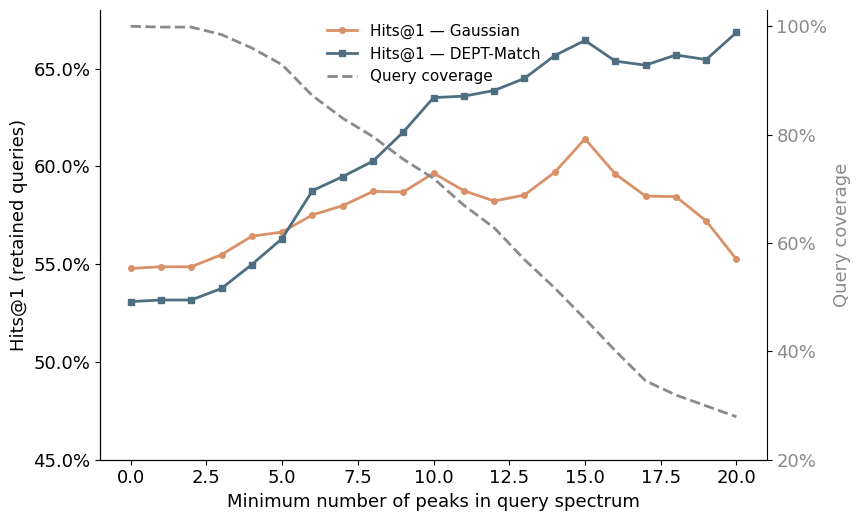

In [3]:
curve = pd.read_parquet(OPT_DIR / "peak_count" / "curve.parquet")

fig, axL = plt.subplots(figsize=(8.8, 5.4))
axL.plot(curve["min_peaks"], curve["hits1_Gaussian"], "-o", color=AMBER, lw=2, ms=4, label="Hits@1 — Gaussian")
axL.plot(curve["min_peaks"], curve["hits1_DEPT-Match"], "-s", color=SLATE, lw=2, ms=4, label="Hits@1 — DEPT-Match")
axL.set_xlabel("Minimum number of peaks in query spectrum", fontsize=13)
axL.set_ylabel("Hits@1 (retained queries)", fontsize=13)
axL.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
axL.set_ylim(45, 68)
axL.locator_params(axis="y", nbins=5)

axR = axL.twinx()
axR.spines["right"].set_visible(True)
axR.plot(curve["min_peaks"], curve["coverage_pct"], "--", color=GREY, lw=2, label="Query coverage")
axR.set_ylabel("Query coverage", fontsize=13, color=GREY)
axR.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
axR.tick_params(axis="y", labelcolor=GREY)
axR.set_ylim(20, 103)
axR.locator_params(axis="y", nbins=5)

h1, l1 = axL.get_legend_handles_labels()
h2, l2 = axR.get_legend_handles_labels()
axL.legend(h1 + h2, l1 + l2, frameon=False, fontsize=11, loc="upper center", ncol=1)
fig.tight_layout()
fig.savefig(FIG_DIR / "peak_count.png", dpi=DPI, bbox_inches="tight")
print(curve.to_string(index=False))
plt.show()